Import Libraries

In [2]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading dataset
df = pd.read_csv('train.csv')
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## Data Processing 1

In [4]:
# checking the shape of the dataset.
df.shape

(668665, 15)

### Drop unused column

In [5]:
df = df.drop(['id'], axis=1)
df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


### Check Null/Missing values

In [6]:
df.isnull().sum()

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

## Check data types of columns

In [7]:
# typecast environmental_concern_level fro float to int
df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].astype(int)
df.dtypes

Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level      int64
Gender                             str
City_Type                          str
Current_Car_Type                   str
Home_Charging_Possible             str
Subsidy_Available                  str
Range_Anxiety_Level                str
Will_Buy_EV                        str
dtype: object

### Check Duplicate values

In [8]:
df.duplicated().sum()

np.int64(0)

### Descriptive statistics

In [9]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


Dataset looks statistically clean--- But outliers were dectected in the Annual Income USD and Daily commute and Number of cars owned. This will be exlored to know if they are worth removing or not.

### Explaratory Data Analysis

In the EDA, I'll be looking at the distribution of the data, the correlation between features and the target variable and the relationship between the features and the target variable. 

I'll start by loooking at the distribution of the dara, followed by the relationship between features and the target variable. 

## Quantitative Data with Target variable.

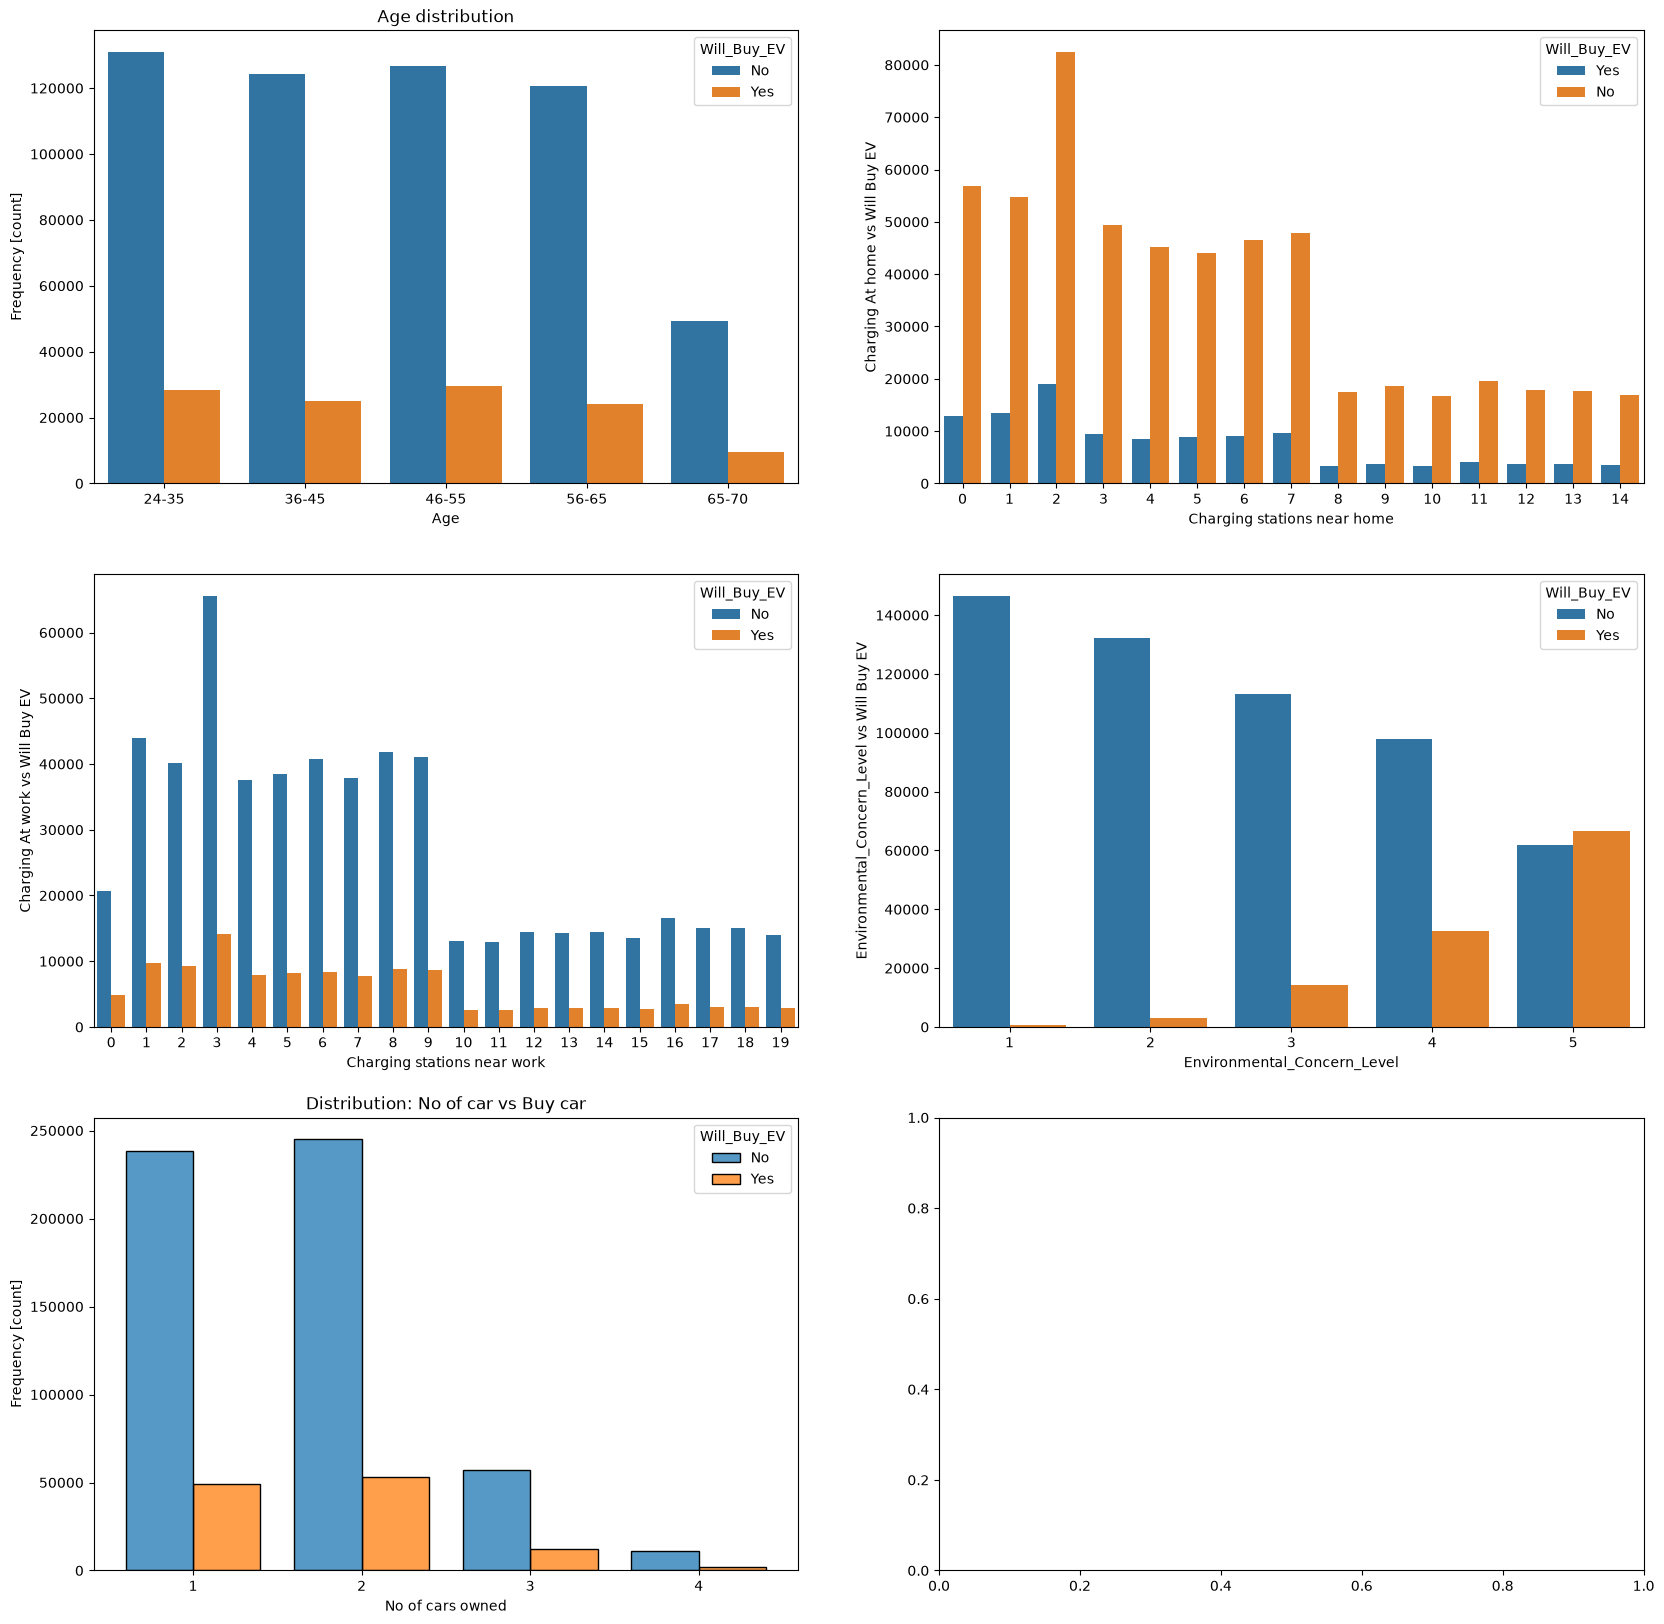

In [40]:
fig, ax = plt.subplots(3,2, figsize=(20,20))

# age is too spreadout to explore. We use age bracket instead of the normal age.
df['Age_group'] = pd.cut(df['Age'], bins=[24, 35, 45, 55, 65, 70], labels=['24-35', '36-45', '46-55', '56-65', '65-70' ])

sns.countplot(
    data=df, 
    x='Age_group', 
    hue='Will_Buy_EV', 
    ax=ax[0,0])
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Frequency [count]')
ax[0,0].set_title('Age distribution');

sns.countplot(
    data=df,
    x='Charging_Stations_Near_Home',
    hue='Will_Buy_EV',
    ax=ax[0,1]
)
ax[0,1].set_xlabel('Charging stations near home')
ax[0,1].set_ylabel('Frequecy [count]')
ax[0,1].set_ylabel('Charging At home vs Will Buy EV');

sns.countplot(
    data=df,
    x='Charging_Stations_Near_Work',
    hue='Will_Buy_EV',
    ax=ax[1,0]
)
ax[1,0].set_xlabel('Charging stations near work')
ax[1,0].set_ylabel('Frequecy [count]')
ax[1,0].set_ylabel('Charging At work vs Will Buy EV');

sns.countplot(
    data=df,
    x='Environmental_Concern_Level',
    hue='Will_Buy_EV',
    ax=ax[1,1]
)
ax[1,1].set_xlabel('Environmental_Concern_Level')
ax[1,1].set_ylabel('Frequecy [count]')
ax[1,1].set_ylabel('Environmental_Concern_Level vs Will Buy EV');

sns.histplot(
    data=df,
    x='Number_of_Cars_Owned',
    hue='Will_Buy_EV',
    multiple='dodge',
    discrete=True,
    shrink=0.8,
    ax=ax[2,0]
)
ax[2,0].set_xticks([1, 2, 3, 4])
ax[2,0].set_xlabel('No of cars owned')
ax[2,0].set_ylabel('Frequency [count]')
ax[2,0].set_title('Distribution: No of car vs Buy car');

This plot shows the distributio of the target variable with the quantitave variable in the data.

Most of the statistical analysis were found to correlate with the visualzation.

The outliers detected in the Number of cars column are very reasonable in reality and are not worth taking down because having a car of 4 is actually very possible and not a big deal.

Text(0.5, 1.0, 'Daily_Commute_km vs Buy EV')

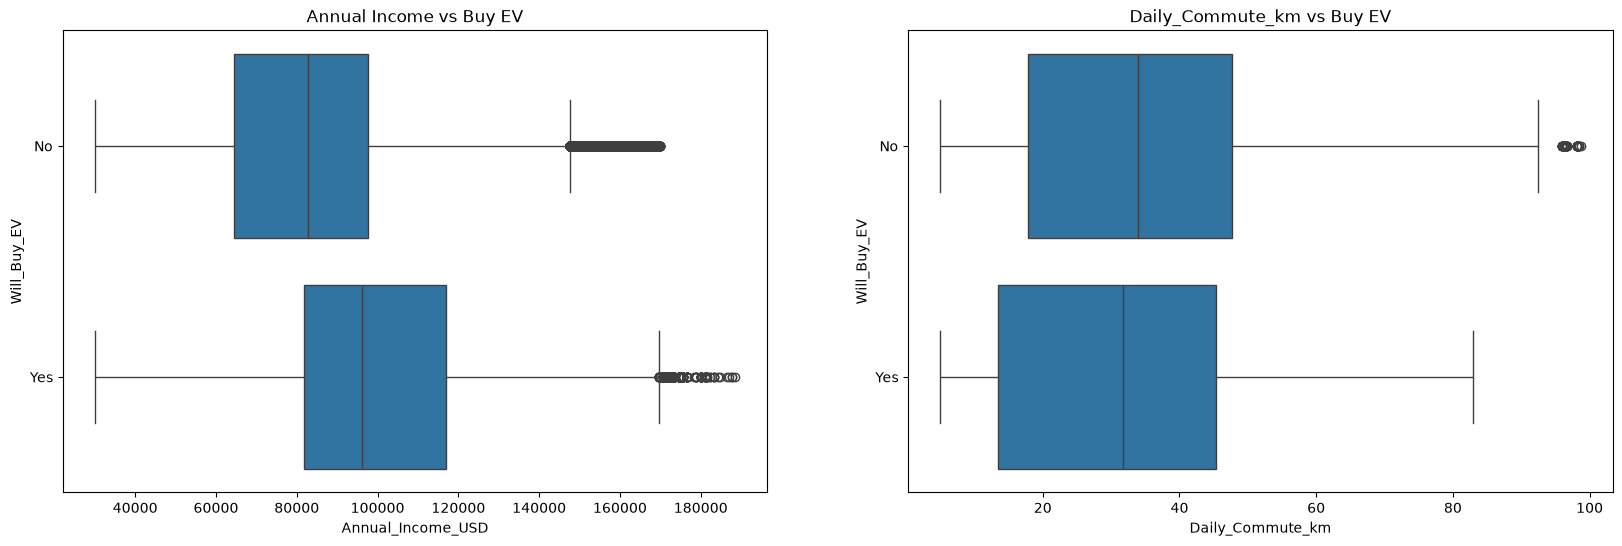

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(20,6))


sns.boxplot(
    df,
    x='Annual_Income_USD',
    y='Will_Buy_EV',
    ax=ax[0]
)
ax[0].set_xlabel('Annual_Income_USD')
ax[0].set_ylabel('Will_Buy_EV')
ax[0].set_title('Annual Income vs Buy EV')


sns.boxplot(
    df,
    x='Daily_Commute_km',
    y='Will_Buy_EV',
    ax=ax[1]
)
ax[1].set_xlabel('Daily_Commute_km')
ax[1].set_ylabel('Will_Buy_EV')
ax[1].set_title('Daily_Commute_km vs Buy EV')

This plot shows the outliers.

### Categorical Variables

Text(1065.8401791351007, 0.5, 'Frequency [count]')

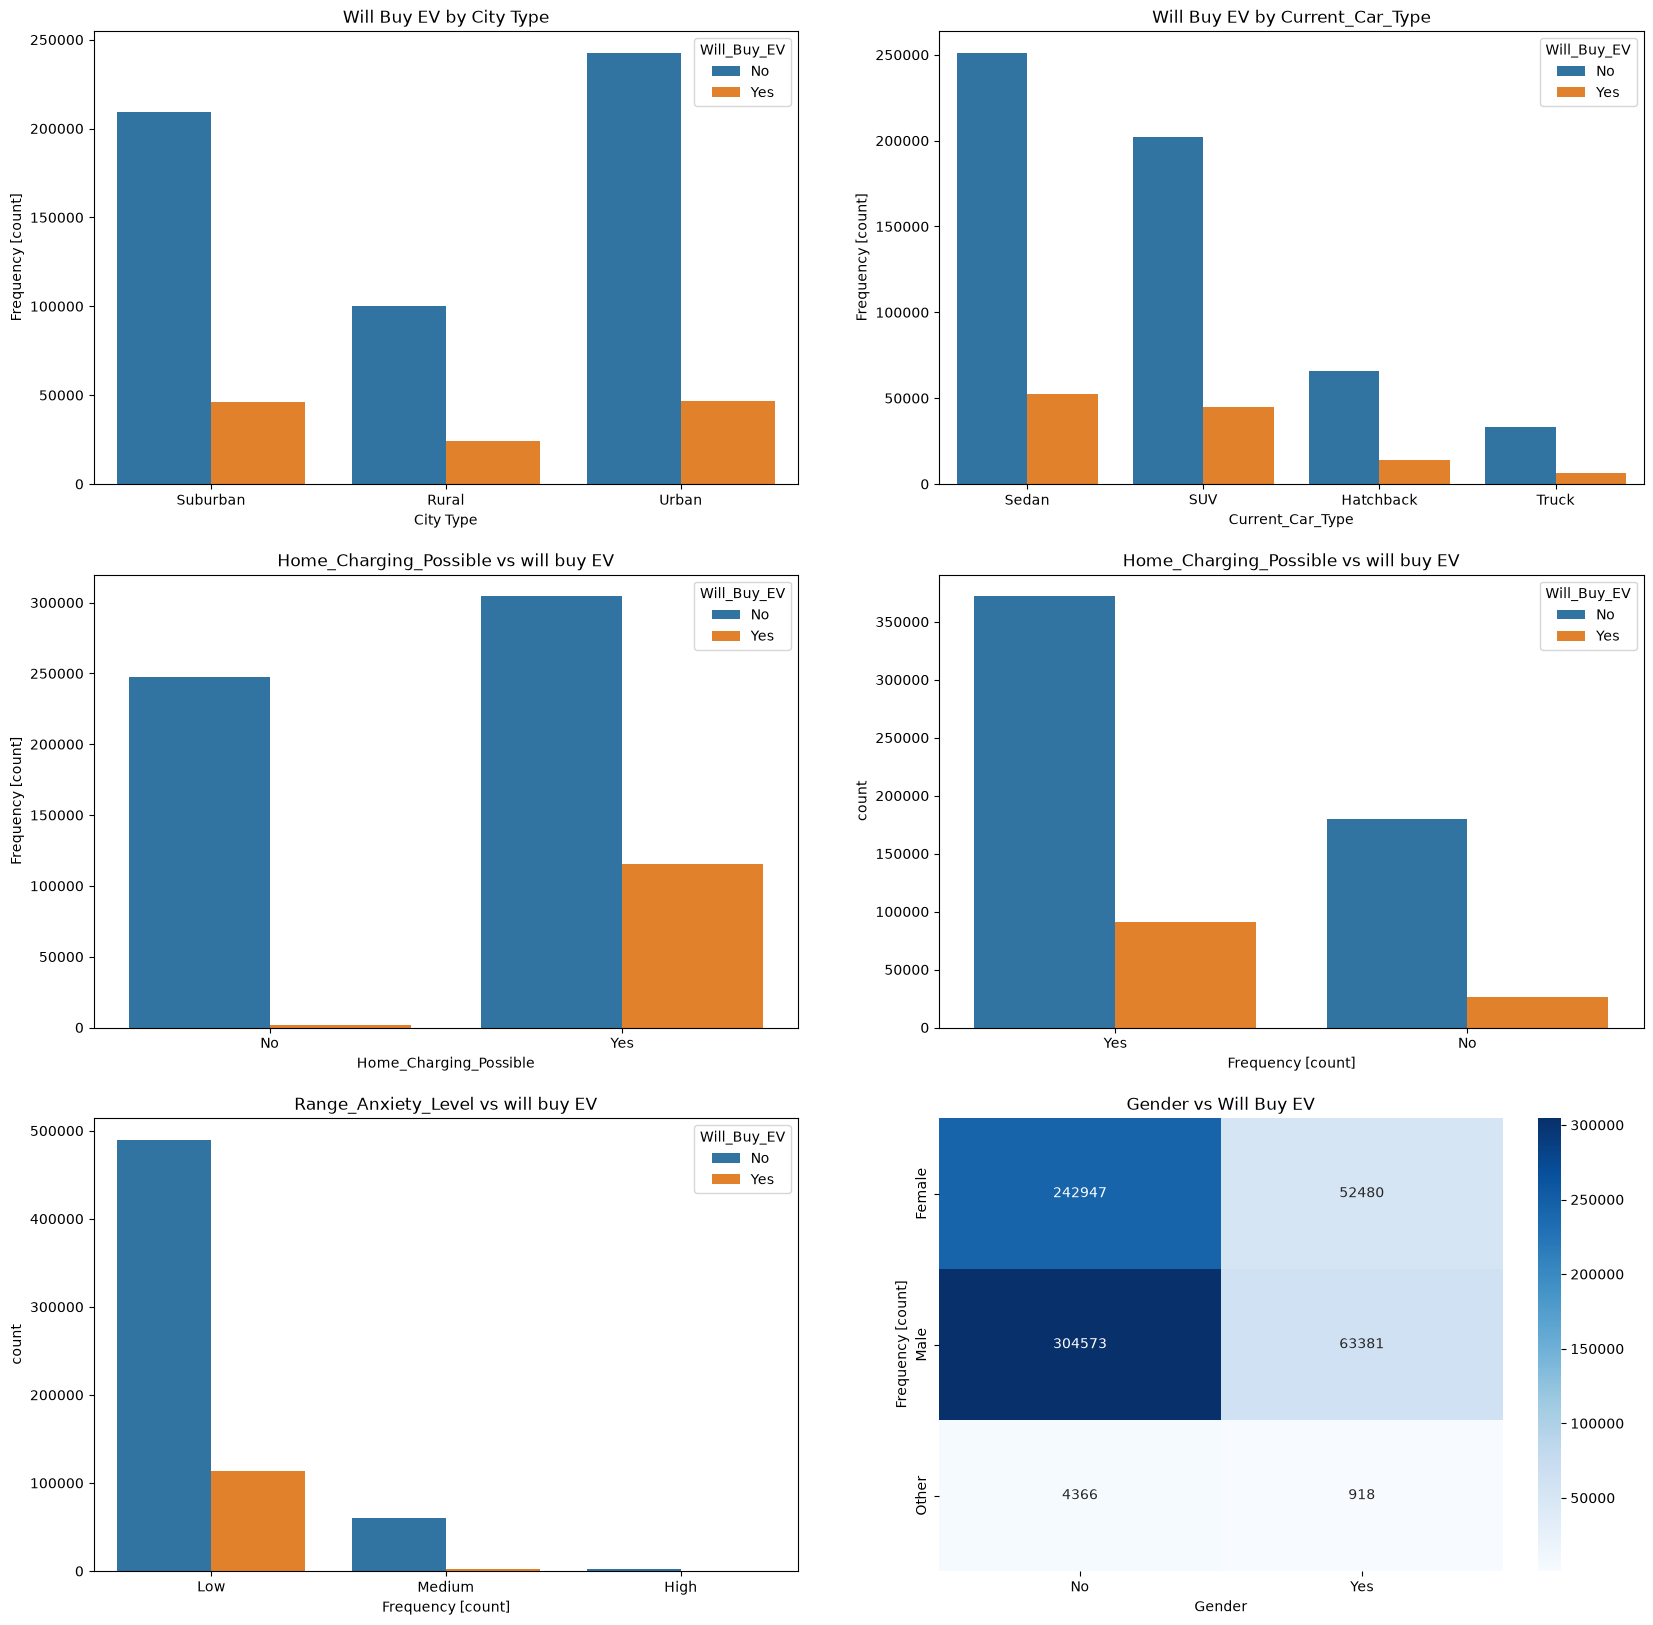

In [68]:
fig, ax = plt.subplots(3,2, figsize=(20,20))


sns.countplot(
    data=df,
    x='City_Type',
    hue='Will_Buy_EV',
    ax=ax[0,0]
)
ax[0,0].set_title('Will Buy EV by City Type')
ax[0,0].set_xlabel('City Type')
ax[0,0].set_ylabel('Frequency [count]')

sns.countplot(
    data=df,
    x='Current_Car_Type',
    hue='Will_Buy_EV',
    ax=ax[0,1]
)
ax[0,1].set_title('Will Buy EV by Current_Car_Type')
ax[0,1].set_xlabel('Current_Car_Type')
ax[0,1].set_ylabel('Frequency [count]')


sns.countplot(
    df,
    x='Subsidy_Available',
    hue='Will_Buy_EV',
    ax=ax[1,0]
)
ax[1,0].set_xlabel('Home_Charging_Possible')
ax[1,0].set_ylabel('Frequency [count]')
ax[1,0].set_title('Home_Charging_Possible vs will buy EV')


sns.countplot(
    df,
    x='Home_Charging_Possible',
    hue='Will_Buy_EV',
    ax=ax[1,1]
)
ax[1,1].set_xlabel('Home_Charging_Possible')
ax[1,1].set_xlabel('Frequency [count]')
ax[1,1].set_title('Home_Charging_Possible vs will buy EV')



sns.countplot(
    df,
    x='Range_Anxiety_Level',
    hue='Will_Buy_EV',
    ax=ax[2,0]
)
ax[2,0].set_xlabel('Range_Anxiety_Level')
ax[2,0].set_xlabel('Frequency [count]')
ax[2,0].set_title('Range_Anxiety_Level vs will buy EV')

ct = pd.crosstab(df['Gender'], df['Will_Buy_EV'])
sns.heatmap(
    ct, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    ax=ax[2,1]
    )

ax[2,1].set_title('Gender vs Will Buy EV')
ax[2,1].set_xlabel('Gender')
ax[2,1].set_ylabel('Frequency [count]')